In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from matplotlib.transforms import offset_copy
from matplotlib import colors

from mpl_toolkits.axes_grid1 import make_axes_locatable

In [2]:
%run LittRuP__import_functions.ipynb

In [3]:
# chemins vers fichiers Data et Images

BASE_DIR = Path.cwd()

if BASE_DIR.name == "Notebooks":
    BASE_DIR = BASE_DIR.parent

DAT_DIR = BASE_DIR / "Data"
IMG_DIR = BASE_DIR / "Images"
DOC_DIR = BASE_DIR / "Docs"

In [4]:
# import matrice étendue

matrix_all_extended = pd.read_csv(DAT_DIR / "LittRu_matrix_all_extended.csv", sep=',', header=0)

In [5]:
# SELECTION de la matrice des identifiants étendus (Works...->)

cols_ids_extended = ["Works", "Author", "Birth", "Death", "Period", "Composed", "When", "Name", "CutOff"]

matrix_ids_extended = matrix_all_extended[cols_ids_extended]

In [6]:
# indique que les thèmes sont toutes les colonnes situées après "CutOff"

theme_cols = matrix_all_extended.columns[
    matrix_all_extended.columns.get_loc("CutOff") + 1:
]

**Nombre d'auteurs par période (semi-séculaire)**<br>
**[calculé par rapport à la date de décès]**<br>
**'[1900-1950[', '[1850-1900[', '[1950-2000[', '>2000', '[1800-1850[', '<1800'**

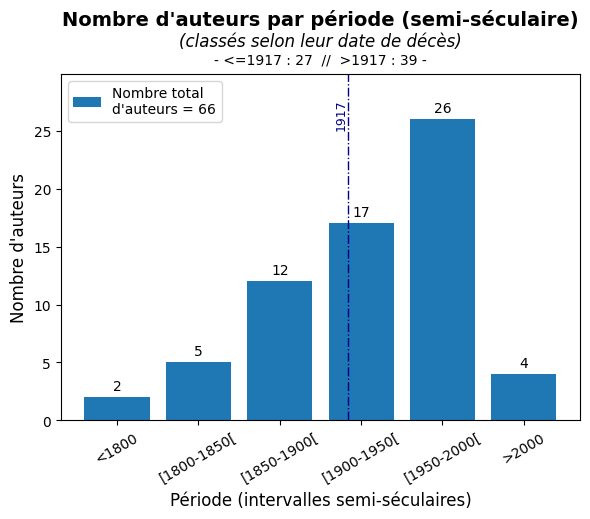

In [7]:
# ordre chronologique souhaité imposé
cutoff_order = [
    "<=1917",
    ">1917"
]

# compter les auteurs uniques par rapport à 1917
authors_by_cutoff = (
    matrix_ids_extended 
    .drop_duplicates(subset=["Author"]) # évite de compter plusieurs fois un même auteur lorsqu’il apparaît dans plusieurs œuvres
    .groupby("CutOff")["Author"]
    .nunique()
    .reindex(cutoff_order, fill_value=0)
)

pred_17 = authors_by_cutoff.tolist()[0]   # <=1917 : le résultat est 27
post_17 = authors_by_cutoff.tolist()[1]   # >1917 : le résultat est 39

# ordre chronologique souhaité imposé
period_order = [
    "<1800",
    "[1800-1850[",
    "[1850-1900[",
    "[1900-1950[",
    "[1950-2000[",
    ">2000"
]

# compter les auteurs uniques par période
authors_by_period = (
    matrix_ids_extended
    .drop_duplicates(subset=["Author"]) # évite de compter plusieurs fois un même auteur lorsqu’il apparaît dans plusieurs œuvres
    .groupby("Period")["Author"]
    .nunique()
    .reindex(period_order, fill_value=0)
)

N_authors = authors_by_period.values.sum().tolist()

# graphique
fig, ax = plt.subplots(figsize=(6, 5))

bars = ax.bar(authors_by_period.index, 
              authors_by_period.values, 
              label = "Nombre total \n" + "d'auteurs = " + f"{N_authors:.0f}"
)

ax.bar_label(
    bars,
    labels=authors_by_period.values,
    padding=3,
    fontsize=10
)

# Dans le graphique, les catégories : ["<1800", "[1800-1850[", "[1850-1900[", ...]
# sont traitées par Matplotlib comme des positions discrètes
# Autrement dit, en interne, Matplotlib les convertit automatiquement en : 0, 1, 2, 3, 4, 5
# la date 1917 appartient à l’intervalle : [1900-1950[ qui est à la position 3...
# il faut convertir 1917 en une position relative sur l’axe catégoriel !

# Dans ce cas :
x_1917 = 2 + (1917 - 1875) / (1925 - 1875) 

# Ensuite:
ax.axvline(x=x_1917, linestyle="dashdot", linewidth=1, color="darkblue")

ax.text(
    x_1917,
    25,
    "1917",
    rotation=90,
    va="bottom",
    ha="right",
    fontsize=9,
    color="darkblue"
)

ax.set_xlabel("Période (intervalles semi-séculaires)", fontsize=12)
ax.set_ylabel("Nombre d'auteurs", fontsize=12)

ax.tick_params(axis="x", rotation=30)
ax.set_ylim(0, authors_by_period.max() * 1.15)
plt.legend(loc="best")

fig.tight_layout(rect=[0, 0, 1, 0.93])

titres(
    fig,
    ax,
    t1="Nombre d'auteurs par période (semi-séculaire)", y1=35,
    t2="(classés selon leur date de décès)", y2=20,
    t3=f"- <=1917 : {pred_17}  //  >1917 : {post_17} -", y3=7
)

fig.savefig(IMG_DIR / "auteurs_périodes_semi_séculaires.png", dpi=300)

plt.show()

**Auteurs par périodes de vie**

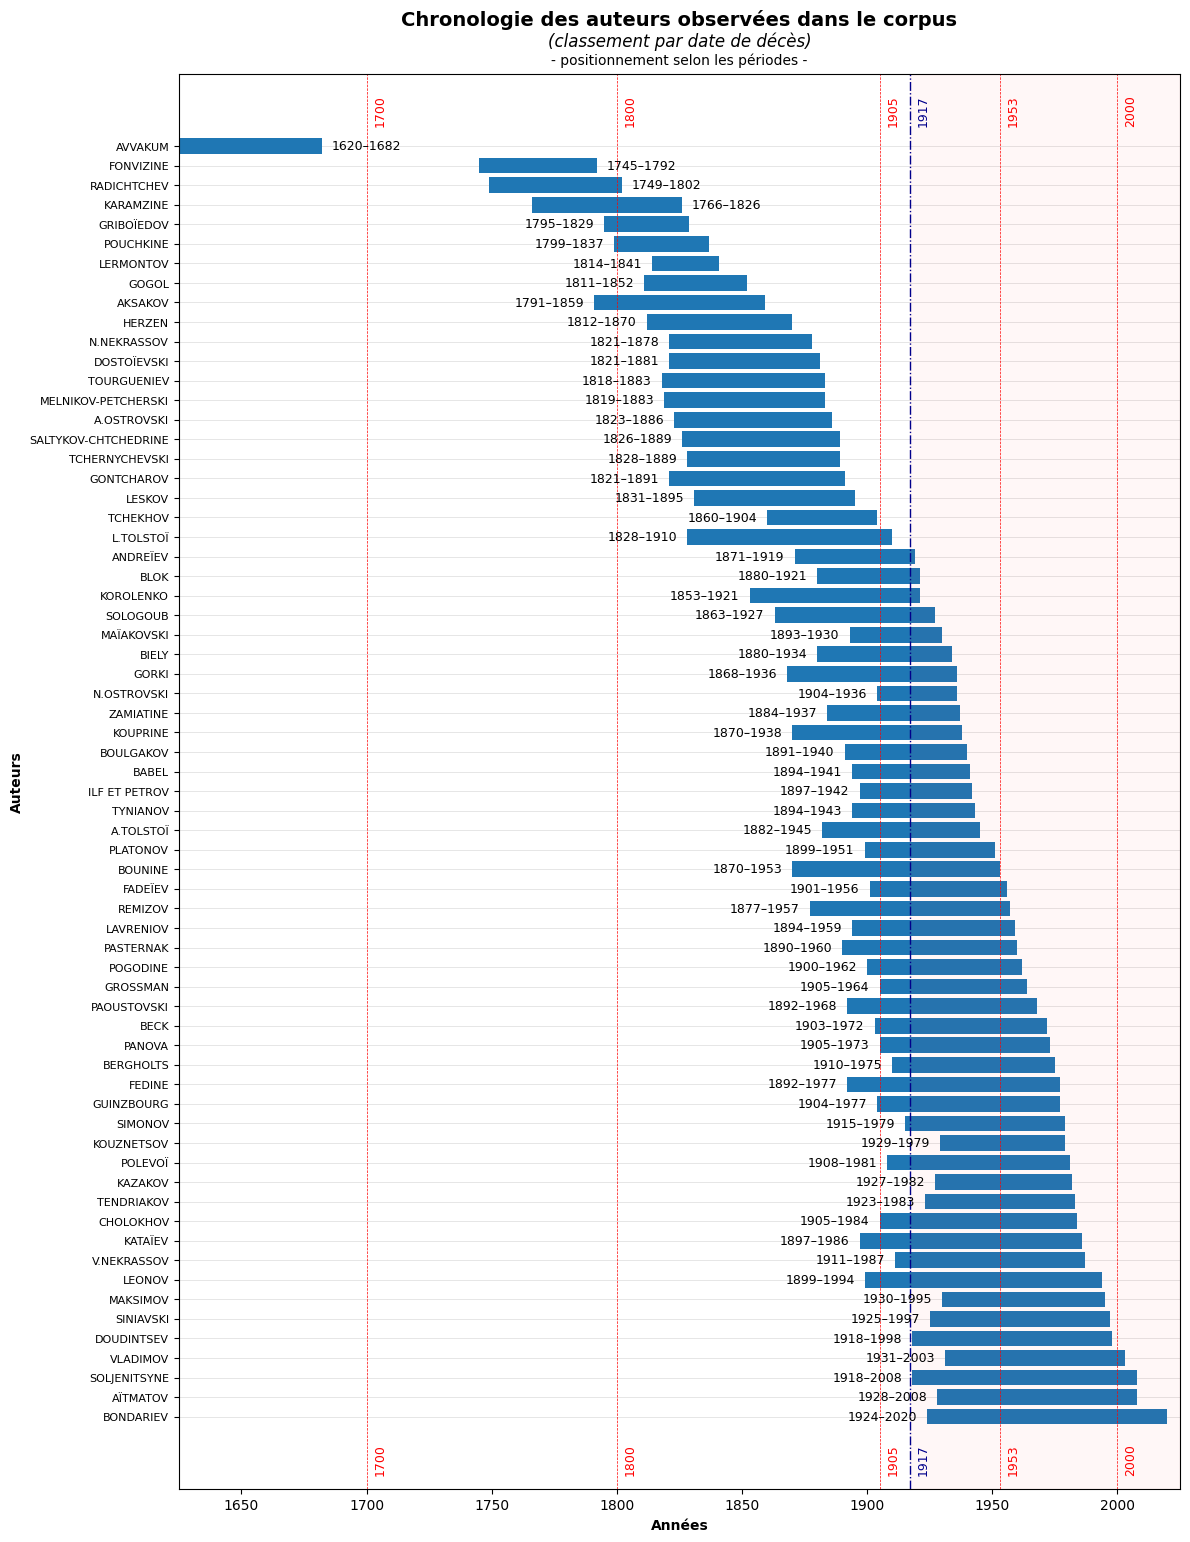

In [8]:

# Fichier des auteurs

authors_life = (
    matrix_ids_extended
    .drop_duplicates(subset=["Author"]) # évite de compter plusieurs fois un même auteur lorsqu’il apparaît dans plusieurs œuvres
)

# Tri par date de décès
authors_life = authors_life.sort_values("Death")

# Durée de vie
authors_life["Lifespan"] = authors_life["Death"] - authors_life["Birth"]

# Graphique avec auteurs les plus anciens en haut
fig, ax = plt.subplots(figsize=(12, 16))

ax.invert_yaxis()

ax.barh(
    y=authors_life["Author"],
    width=authors_life["Lifespan"],
    left=authors_life["Birth"]
)

# lignes verticales de séparations
from matplotlib.transforms import offset_copy

trans = offset_copy(ax.transData, fig=fig, x=5, y=0, units='points')

for year_cen in [1700, 1800, 1905, 1953, 2000]:
    ax.axvline(x=year_cen, linestyle="dashed", linewidth=0.5, color="red")

    ax.text(
        year_cen,
        -1,
        str(year_cen),
        transform=trans,
        rotation=90,
        va="bottom",
        fontsize=9,
        color="red"
    )

    ax.text(
        year_cen,
        68,
        str(year_cen),
        transform=trans,
        rotation=90,
        va="bottom",
        fontsize=9,
        color="red"
    )

ax.axvline(x=1917, linestyle="dashdot", linewidth=1, color="darkblue")

ax.text(
    1917,
    -1,
    str(1917),
    transform=trans,
    rotation=90,
    va="bottom",
    fontsize=9,
    color="darkblue"
)

ax.text(
    1917,
    68,
    str(1917),
    transform=trans,
    rotation=90,
    va="bottom",
    fontsize=9,
    color="darkblue"
)

# Positionner les dates
xmin = authors_life["Birth"].min()
xmax = authors_life["Death"].max()

switch_margin = 150   # seuil : décide gauche/droite pour les dates
text_offset = 4       # écart réel entre label et barre des dates

for idx, row in authors_life.iterrows():

    label = f'{row["Birth"]}–{row["Death"]}'

    if row["Birth"] - xmin < switch_margin:
        # label à droite
        x_label = row["Death"] + text_offset
        ha = "left"
    else:
        # label à gauche
        x_label = row["Birth"] - text_offset
        ha = "right"

    ax.text(
        x_label,
        row["Author"],
        label,
        va="center",
        ha=ha,
        fontsize=9
    )

# coloration de la zone >1917
ax.axvspan(
    1917,
    2025,
    color="red",
    alpha=0.03
)

# lignes horizontales d'alignement des auteurs
ax.hlines(
#    y=author_stats.index,
    y=authors_life["Author"],
    xmin=1625,
    xmax=2025,
    color="lightgrey",
    linewidth=0.4,
    zorder=0
)

ax.set_xlabel("Années", fontweight="bold")
ax.set_xlim(1625, 2025)
ax.set_ylabel("Auteurs", fontweight="bold")
ax.tick_params(axis="y", labelsize=8)

fig.tight_layout(rect=[0, 0, 1, 0.93])

titres(
    fig,
    ax,
    t1="Chronologie des auteurs observées dans le corpus", y1=35,
    t2="(classement par date de décès)", y2=20,
    t3="- positionnement selon les périodes -", y3=7
)

fig.savefig(IMG_DIR / "auteurs_dates.png", dpi=300)

plt.show()

**Heatmap des profils thématiques auteurs**

In [9]:
# profil thématique par auteur

matrix_author_profile = (
    matrix_all_extended
    .groupby("Author")[theme_cols]   # Regrouper les lignes (thèmes) appartenant au même auteur (=> mis en INDEX !)
    .sum()                           # appliquer une somme colonne par colonne à l’intérieur de chaque groupe d’auteur
)

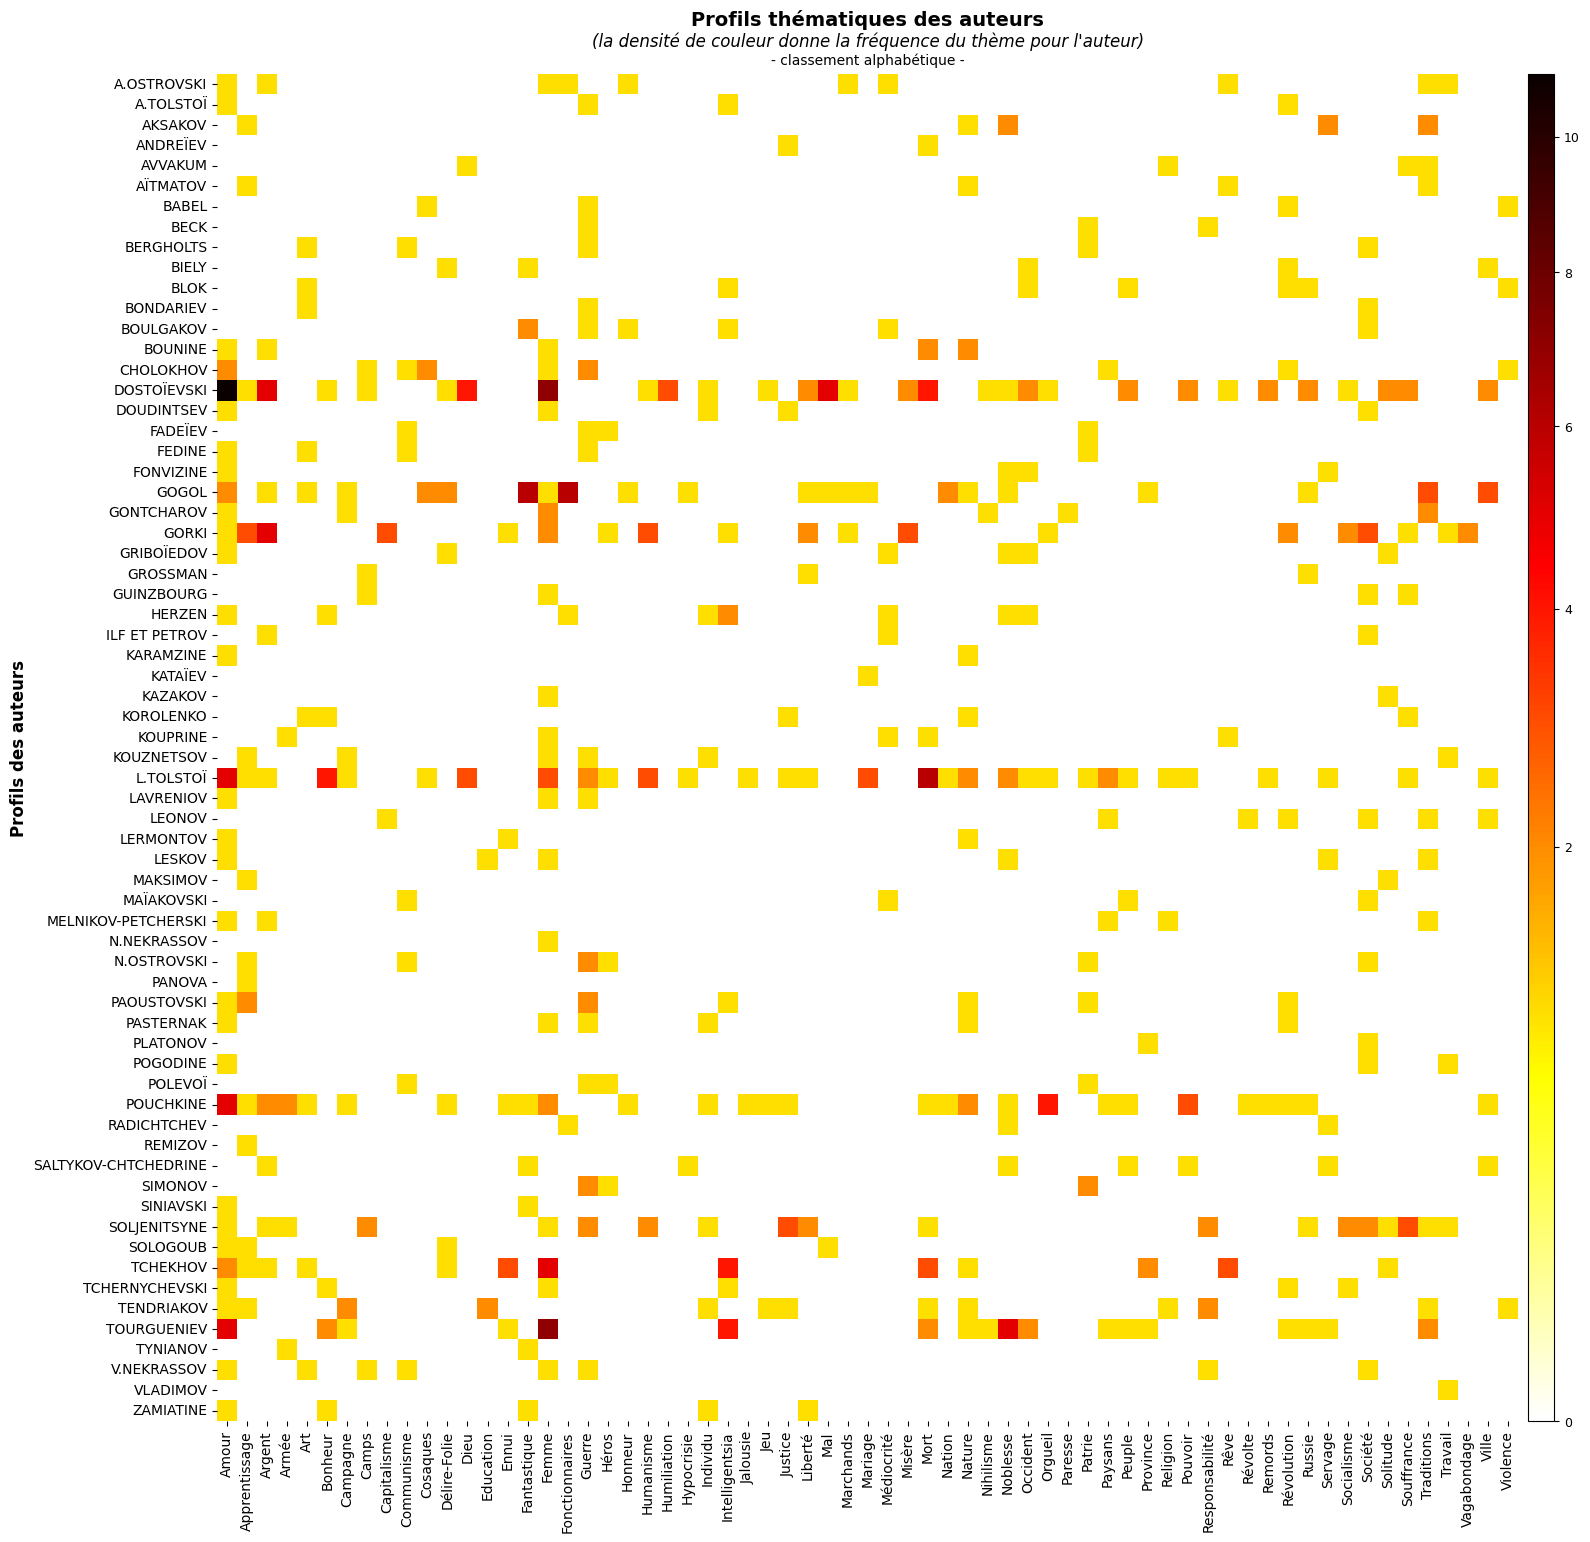

In [10]:
# HEATMAP

fig, ax = plt.subplots(figsize=(16, 16))

sns.heatmap(
    matrix_author_profile,
    cmap="hot_r",
    cbar=False,
    norm=colors.PowerNorm(gamma=0.5),
    ax=ax
)

im = ax.collections[0]

divider = make_axes_locatable(ax)

cax = divider.append_axes(
    "right",
    size="2%",   # largeur de la colorbar
    pad=0.10     # distance au graphique
)

cbar = fig.colorbar(im, cax=cax)
cbar.ax.tick_params(labelsize=9)

ax.set_ylabel("Profils des auteurs", fontsize=12, fontweight="bold")

plt.tight_layout(rect=[0, 0, 1, 0.93]) # réserve de la place au-dessus du graphique

titres(
    fig,
    ax,
    t1="Profils thématiques des auteurs", y1=35,
    t2="(la densité de couleur donne la fréquence du thème pour l'auteur)", y2=20,
    t3="- classement alphabétique -", y3=7
)

plt.savefig(IMG_DIR / "auteurs_profil_thématique.png", dpi=300, bbox_inches="tight")
plt.show()


**Statistiques auteurs pour inclusion tableau**

In [11]:
# 1. Statistiques auteurs
author_stats = pd.DataFrame({
    "total": matrix_author_profile.sum(axis=1),
    "n_themes": (matrix_author_profile > 0).sum(axis=1),
    "mean": matrix_author_profile.mean(axis=1),
    "std": matrix_author_profile.std(axis=1)
})

# 2. Classement par volume thématique total
author_stats = author_stats.sort_values(
    by="total",
    ascending=False
)

author_stats["num"] = range(1, len(author_stats) + 1)

# 3. Table de correspondance
legend_authors = (
    author_stats
    .reset_index()
    .rename(columns={"index": "Author"})
    [["num", "Author", "total", "n_themes"]]
)

# 4. Nombre de thèmes utilisables
NT = len(matrix_author_profile.columns)

# 5. Nombre d'auteurs à incruster en tableau
NA = 12


In [12]:
# simple vérification 
author_stats

,total,n_themes,mean,std,num
Author,,,,,
DOSTOÏEVSKI,72,30,1.107692,1.913138,1
L.TOLSTOÏ,55,31,0.846154,1.265291,2
POUCHKINE,41,28,0.630769,0.977389,3
GOGOL,40,22,0.615385,1.220813,4
TOURGUENIEV,39,18,0.600000,1.355544,5
...,...,...,...,...,...
KATAÏEV,1,1,0.015385,0.124035,62
N.NEKRASSOV,1,1,0.015385,0.124035,63
PANOVA,1,1,0.015385,0.124035,64


**Graphique de diversité**

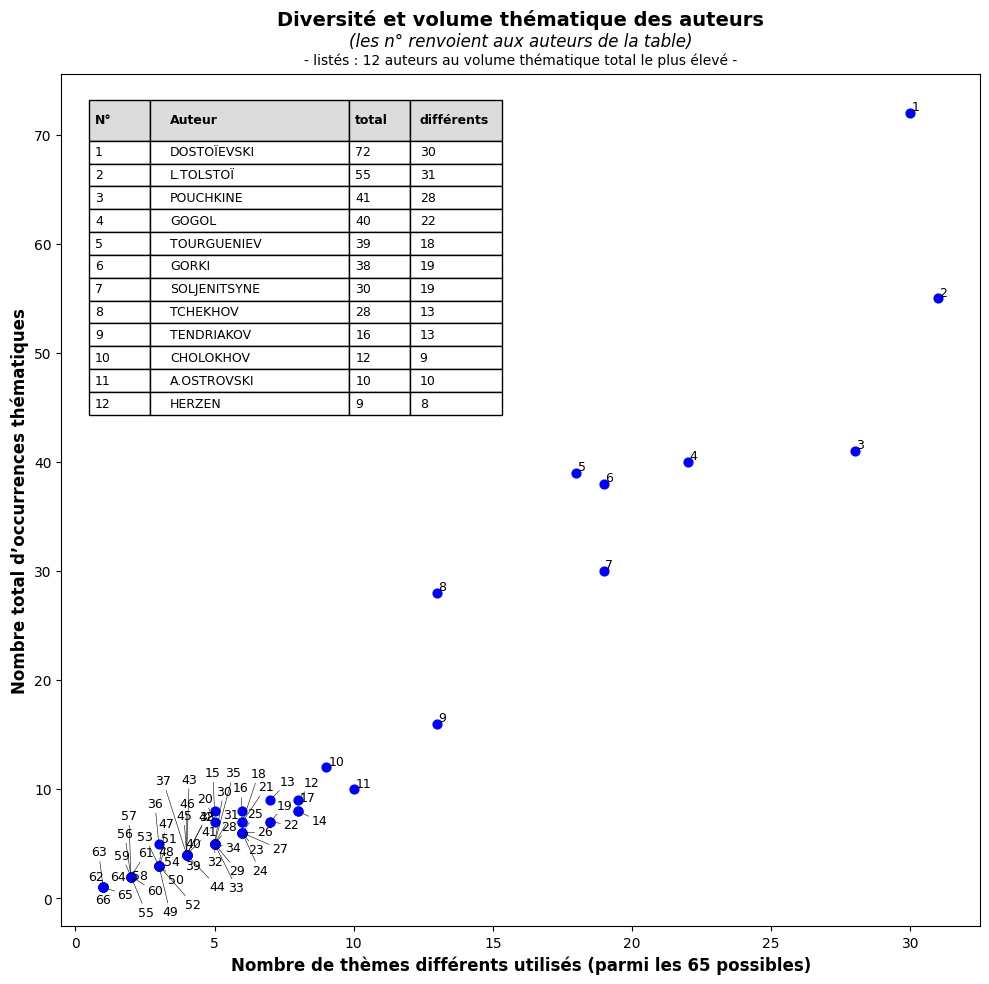

In [13]:
import io
import contextlib
from adjustText import adjust_text

fig, ax = plt.subplots(figsize=(10, 10))

ax.scatter(
    x=author_stats["n_themes"],
    y=author_stats["total"],
    s=40,
    color="blue"
)

texts = []

for author in author_stats.index:

    texts.append(
        ax.text(
            author_stats.loc[author, "n_themes"],
            author_stats.loc[author, "total"],
            str(author_stats.loc[author, "num"]),
            fontsize=9
        )
    )

# Supprime les sorties parasites de adjust_text()
with contextlib.redirect_stdout(io.StringIO()):
    adjust_text(
        texts,
        ax=ax,
        arrowprops=dict(
            arrowstyle="-",
            lw=0.4
        )
    )

ax.set_xlabel(
    f"Nombre de thèmes différents utilisés (parmi les {NT} possibles)",
    fontsize=12,
    fontweight="bold"
)

ax.set_ylabel(
    "Nombre total d’occurrences thématiques",
    fontsize=12,
    fontweight="bold"
)

# Tableau incrusté dans le graphique
table_data = legend_authors.head(NA).values

table = ax.table(
    cellText=table_data,
    colLabels=["N°", "Auteur", "total", "différents"],
    cellLoc="left",
    colLoc="left",
    bbox=[0.03, 0.60, 0.45, 0.37],
    colWidths=[20, 65, 20, 30]
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.0, 1.0)

header_height = table[(0,0)].get_height()

for col in range(4):
    table[(0,col)].set_height(header_height * 1.8)
    table[(0,col)].set_facecolor("gainsboro")
    table[(0,col)].set_text_props(weight="bold", va="center")

fig.tight_layout(rect=[0, 0, 1, 0.93])

titres(
    fig,
    ax,
    t1="Diversité et volume thématique des auteurs", y1=35,
    t2="(les n° renvoient aux auteurs de la table)", y2=20,
    t3=f"- listés : {NA} auteurs au volume thématique total le plus élevé -", y3=7
)

fig.savefig(IMG_DIR / "auteurs_diversité_et_volume_thématique.png", dpi=300)

plt.show()

**Graphique de densité moyenne du profil**

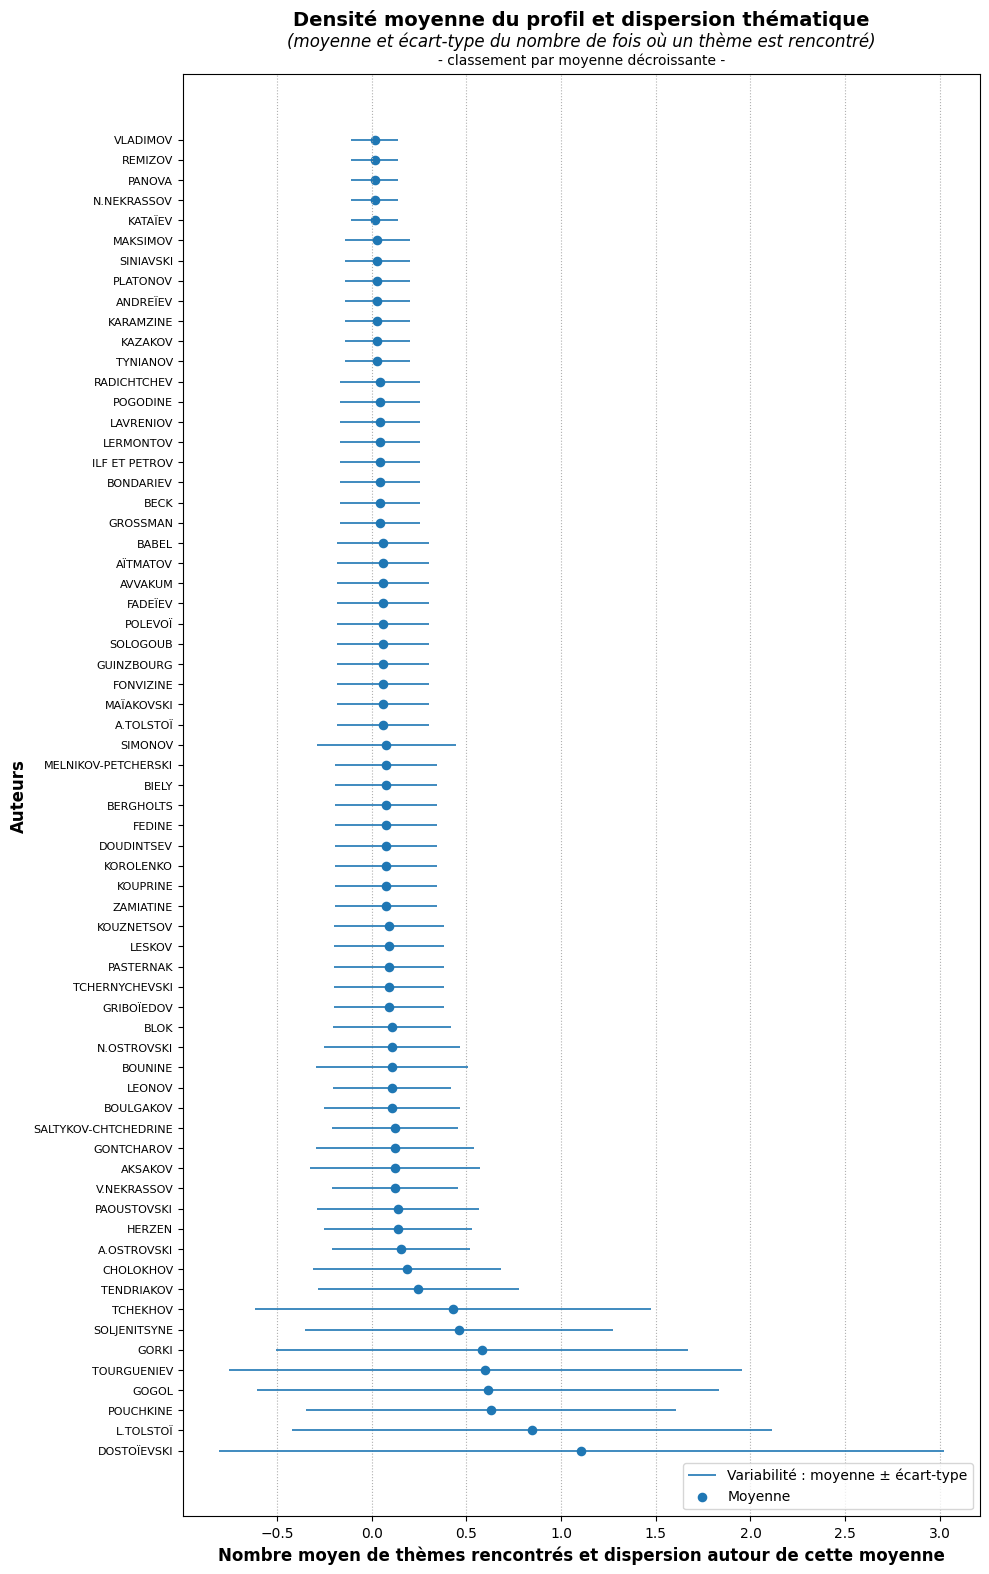

In [14]:
fig, ax = plt.subplots(figsize=(10,16))

y_pos = np.arange(len(author_stats))

# Barre horizontale : moyenne ± écart-type
ax.hlines(
    y=y_pos,
    xmin=author_stats["mean"] - author_stats["std"],
    xmax=author_stats["mean"] + author_stats["std"],
    linewidth=1.2,
    label="Variabilité : moyenne ± écart-type"
)

# Point central : moyenne
ax.scatter(
    x=author_stats["mean"],
    y=y_pos,
    s=35,
    label="Moyenne"
)

ax.grid(
    axis="x",
    linestyle=":",
    alpha=1.0
)

ax.set_yticks(y_pos)
ax.set_yticklabels(author_stats.index)
ax.tick_params(axis="y", labelsize=8)
ax.set_xlabel("Nombre moyen de thèmes rencontrés et dispersion autour de cette moyenne", fontsize=12, fontweight="bold")
ax.set_ylabel("Auteurs", fontsize=12, fontweight="bold")

ax.legend(loc="lower right", frameon=True)

fig.tight_layout(rect=[0, 0, 1, 0.95])

titres(
    fig,
    ax,
    t1="Densité moyenne du profil et dispersion thématique", y1=35,
    t2="(moyenne et écart-type du nombre de fois où un thème est rencontré)", y2=20,
    t3="- classement par moyenne décroissante -", y3=7
)

fig.savefig(IMG_DIR / "auteurs_diversité_thématique.png", dpi=300)

plt.show()
